# **Librairies**



In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Descriptive Analysis**

## **Import du dataframe**

In [12]:
df = pd.read_csv("StudentPerformanceFactors.csv")

## **Visualiation classique du df**

In [13]:
df.head()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

We noticed some missing values ​​for the variables Teacher_Quality, Parent_Education_Level and Distance_From_Home.

In [15]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## **Check Quality**

Checking data quality ensures that:
* All fields are completed
* Values ​​are realistic
* There are no duplicates
* Categories are balanced


In [16]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
print(f"Valeurs manquantes : \n{missing_data}")
print(f"\nPourcentage par rapport aux données : \n{missing_percent}")

Valeurs manquantes : 
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Pourcentage par rapport aux données : 
Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0

**IL FAUT DONC TRAITER LES DONNEES POUR SUPPRIMER LES VALEURS MANQUANTES.**
Pour le traiter les données manquantes j'ai demandé au prof, il faut d'abord voir les variables sont très corrélées aux autres ou si pas trop.
Ensuite comme ça représente que 1% des données, ça serait bête de supprimer toute la colonne. Dcp ce qu'il propose c'est par exemple de regarder les valeurs qui tombent le plus et de remplacer les valeurs inconnus par cette valeur la ou de créer une nouvelle option de réponse pour la colonne "Inconnu" et de traiter avec cette donnée.



**On pourra faire par exemple les deux cas, et changer et tester notre modèek pour les deux cas et garder celui qui a le meilleur rendement, même si la comme ça concerne qu'un petit nombre de données ce n'est pas ça qui va avoir un changement significatif.**


In [17]:
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


## **Traitement des valeurs manquantes**

We know that only three categorical variables have missing values: Teacher_Quality, Parental_Education_Level, and Distance_From_Home.

However, we observe that the number of missing values ​​is very small, representing at most 1.36% of the observations. Given this small proportion, it was decided not to delete the affected rows, but to use an imputation method to preserve the size of the dataset.

Furthermore, the correlation analysis between these three variables and the target variable (Exam_Score) revealed extremely low coefficients of 0.094 and 0.085. Therefore, we can assume that the small influence of these variables on the prediction allows us to hypothesize that the chosen imputation method will have a negligible impact on the model's performance.

To handle these missing values, we will try two different methods that seemed relevant:
1.   Mode Imputation: The missing values ​​will be replaced by the most frequent category (the Mode) of each column. This approach is chosen for the implementation of the standard model.
2.   Imputation by 'Unknown': Missing values ​​will be replaced by the new category 'Unknown'. This approach will be integrated into model improvement tests to determine whether the absence of information, treated as a variable, can refine the prediction results.

In [18]:
colonnes_a_verifier = [
    'Teacher_Quality',
    'Parental_Education_Level',
    'Distance_from_Home'
]

for col in colonnes_a_verifier:
    print(f"\n--- Analyse de la colonne : {col} ---")

    proportions = df[col].value_counts(normalize=True).mul(100).round(2)

    print(f"La valeur la plus fréquente est : {proportions.head(1).index.tolist()[0]}")
    print(f"Elle représente : {proportions.head(1).values[0]} %")



--- Analyse de la colonne : Teacher_Quality ---
La valeur la plus fréquente est : Medium
Elle représente : 60.12 %

--- Analyse de la colonne : Parental_Education_Level ---
La valeur la plus fréquente est : High School
Elle représente : 49.46 %

--- Analyse de la colonne : Distance_from_Home ---
La valeur la plus fréquente est : Near
Elle représente : 59.39 %


In [19]:
colonnes_a_imputer_mode = [
    'Teacher_Quality',
    'Parental_Education_Level',
    'Distance_from_Home'
]

for col in colonnes_a_imputer_mode:

    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

print("\nVérification avec df.info() :")
df.info()


Vérification avec df.info() :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence   

/tmp/ipython-input-288115153.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


## **Visualisation de la distributions des variables**

Distribution des variables numériques


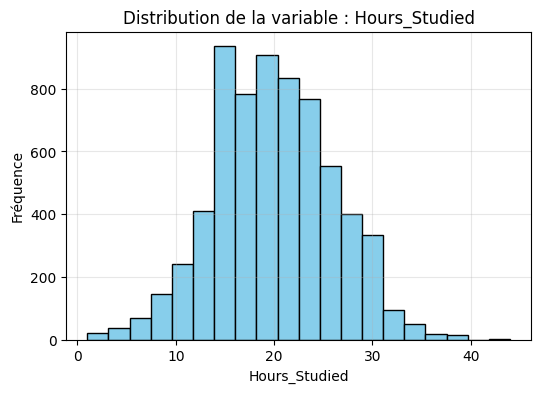

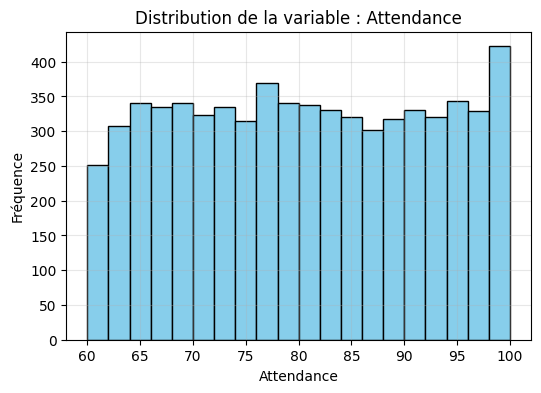

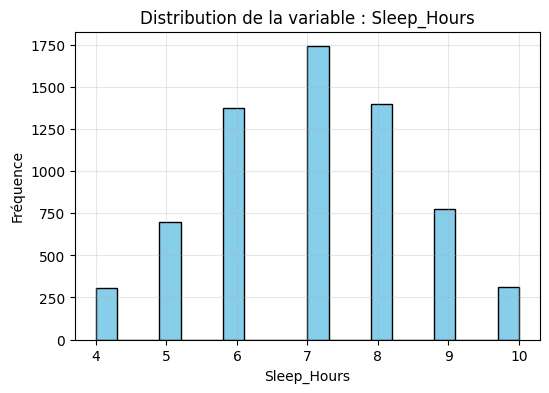

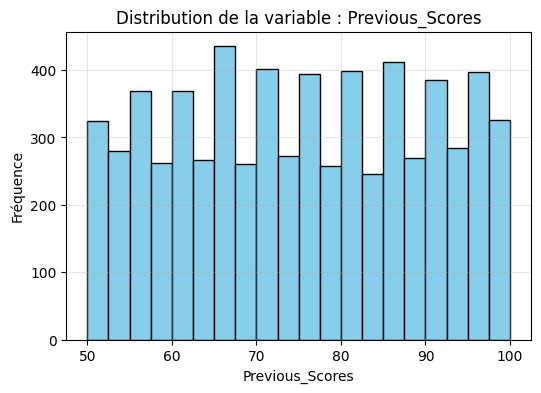

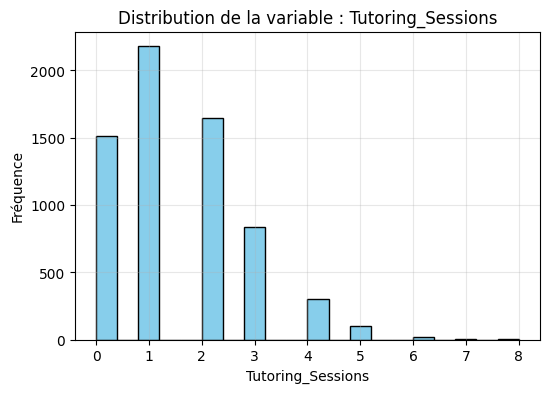

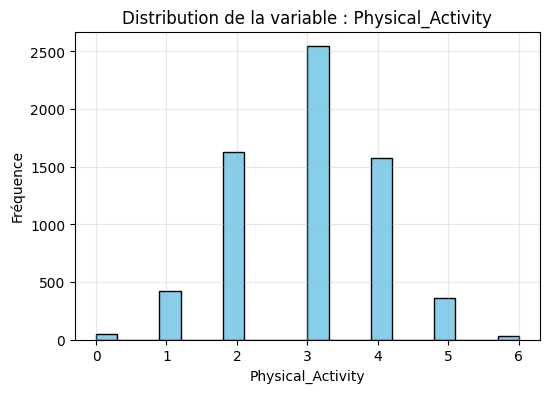

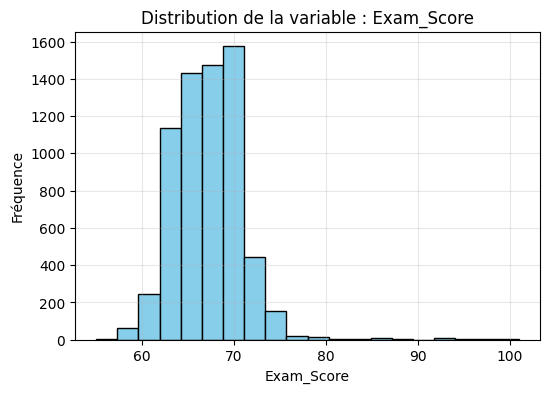

In [20]:
print("Distribution des variables numériques")
colonnes_numeriques = df.select_dtypes(include=['int64', 'float64']).columns

for col in colonnes_numeriques:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f"Distribution de la variable : {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.grid(True, alpha=0.3)
    plt.show()

Distribution des variables catégorielles


/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


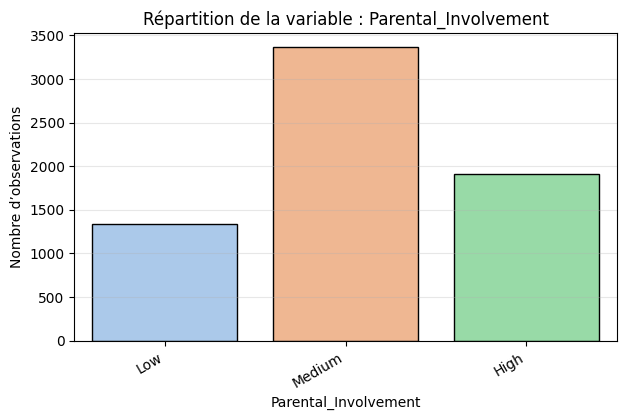

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


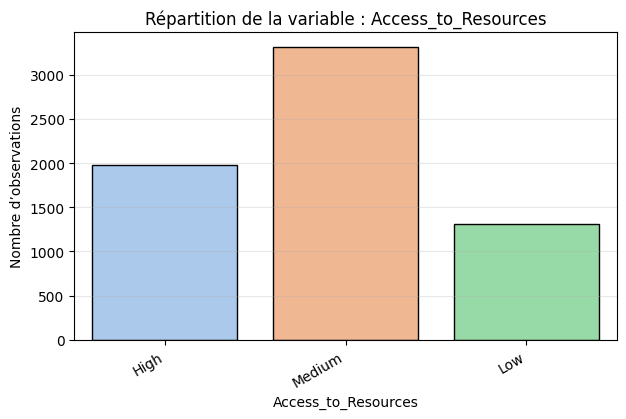

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


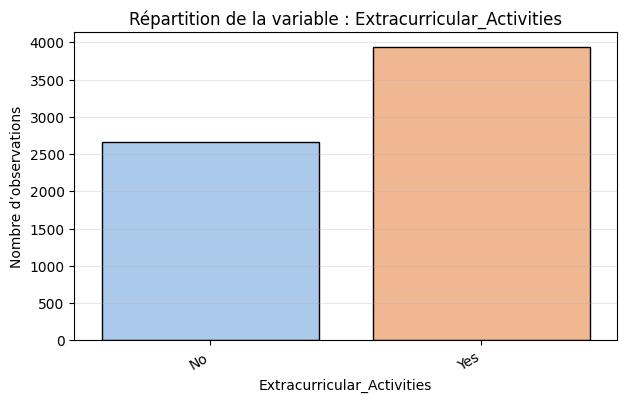

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


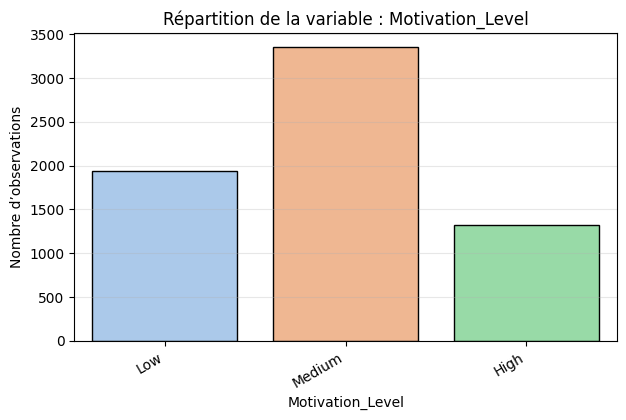

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


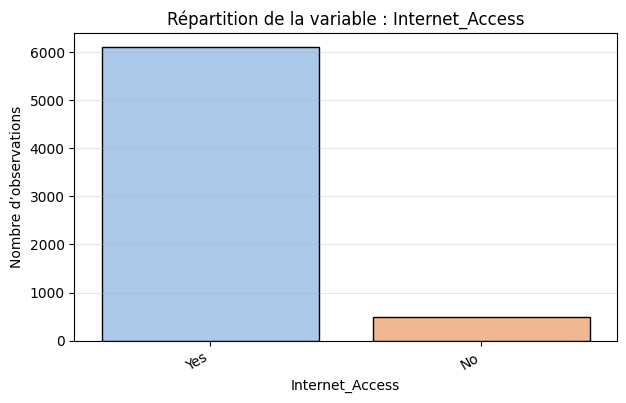

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


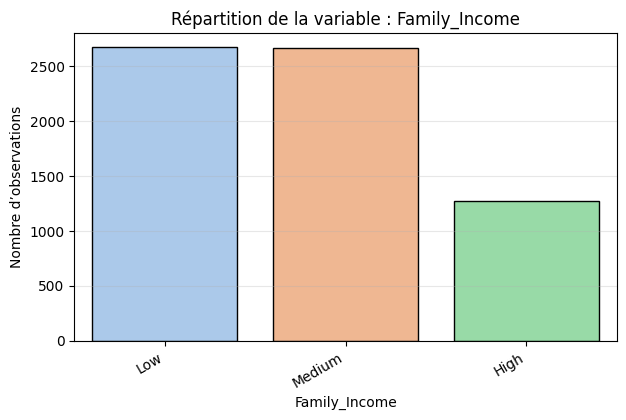

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


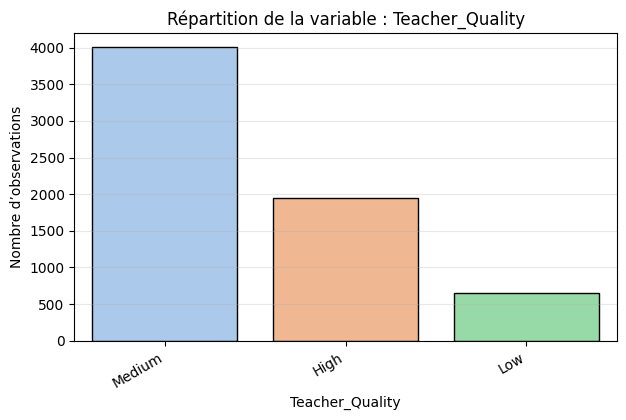

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


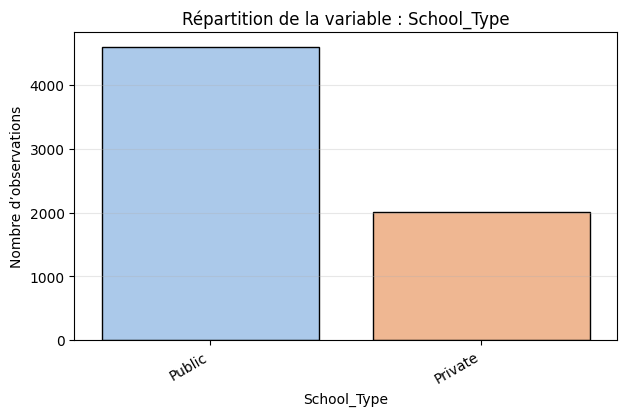

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


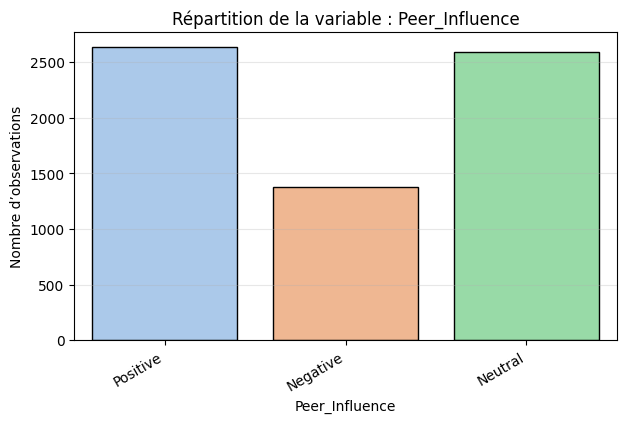

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


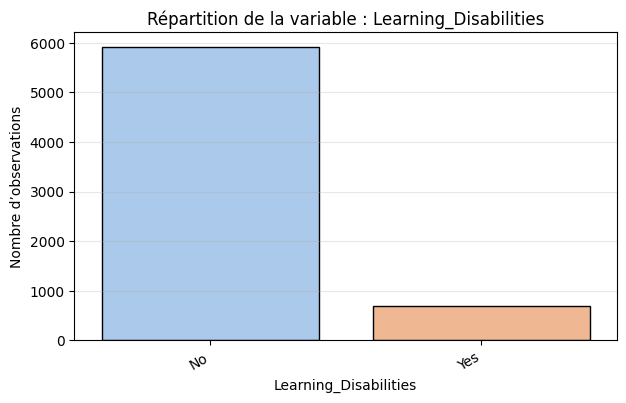

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


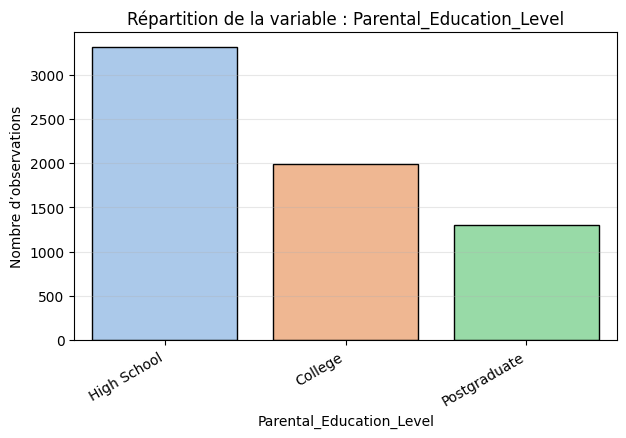

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


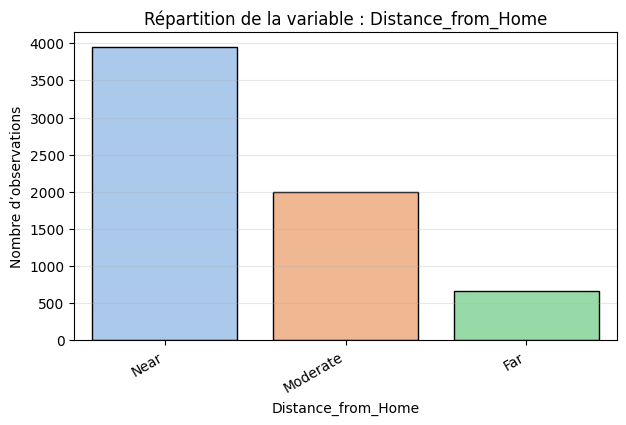

/tmp/ipython-input-875586334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')


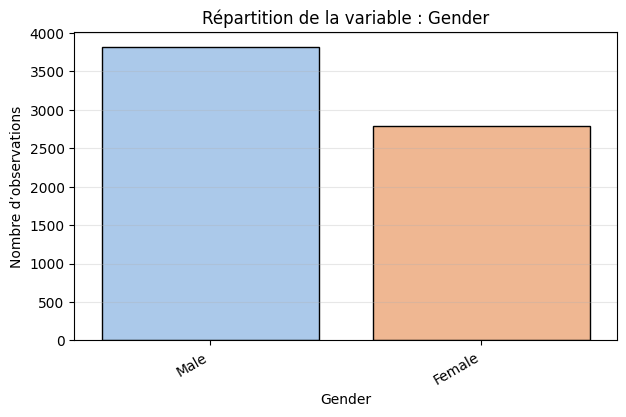

In [21]:
print("Distribution des variables catégorielles")

colonnes_categorielle = df.select_dtypes(include=['object']).columns
for col in colonnes_categorielle:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, data=df, palette="pastel", edgecolor='black')
    plt.title(f"Répartition de la variable : {col}")
    plt.xlabel(col)
    plt.ylabel("Nombre d’observations")
    plt.xticks(rotation=30, ha='right')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()

## **Traitement des variables catégorielles**

Pour traiter les variables catégorielles, nous allons les encoder. Nous avons choisi de ne pas utiliser l'encodage binaire car nous avions souvent plus de deux options de réponse pour chaque variable. Nous n'avons pas opté pour la méthode « numérique » car cela impliquerait, par exemple, que 1 serait plus important que 2. Or, dans le cas de nos variables catégorielles, il n'est pas pertinent d'affirmer que « Faible » est plus fort que « Moyen ». Par conséquent, nous avons décidé d'utiliser la fonction `get_dummies` pour créer une nouvelle colonne pour chaque option, en la remplissant de données binaires afin de pouvoir utiliser et interpréter les corrélations entre les variables.

In [22]:
colonnes_categorielles = df.select_dtypes(include=['object']).columns.tolist()

print("Colonnes catégorielles trouvées :")
for col in colonnes_categorielles:
    print(f"- {col}")

Colonnes catégorielles trouvées :
- Parental_Involvement
- Access_to_Resources
- Extracurricular_Activities
- Motivation_Level
- Internet_Access
- Family_Income
- Teacher_Quality
- School_Type
- Peer_Influence
- Learning_Disabilities
- Parental_Education_Level
- Distance_from_Home
- Gender


In [23]:
def options_variables_categorielles_simple(df):
    variables_cat = df.select_dtypes(include=['object']).columns
    print("OPTIONS POUR CHAQUE VARIABLE  :")
    for colonne in variables_cat:
        valeurs = sorted([v for v in df[colonne].unique() if not pd.isna(v)])
        print(f"{colonne}")
        for i, valeur in enumerate(valeurs, 1):
            print(f"   {i}. {valeur}")
        if df[colonne].isna().sum() > 0:
            print(f"Valeurs manquantes")
options_variables_categorielles_simple(df)

OPTIONS POUR CHAQUE VARIABLE  :
Parental_Involvement
   1. High
   2. Low
   3. Medium
Access_to_Resources
   1. High
   2. Low
   3. Medium
Extracurricular_Activities
   1. No
   2. Yes
Motivation_Level
   1. High
   2. Low
   3. Medium
Internet_Access
   1. No
   2. Yes
Family_Income
   1. High
   2. Low
   3. Medium
Teacher_Quality
   1. High
   2. Low
   3. Medium
School_Type
   1. Private
   2. Public
Peer_Influence
   1. Negative
   2. Neutral
   3. Positive
Learning_Disabilities
   1. No
   2. Yes
Parental_Education_Level
   1. College
   2. High School
   3. Postgraduate
Distance_from_Home
   1. Far
   2. Moderate
   3. Near
Gender
   1. Female
   2. Male


In [24]:
df_encoded = pd.get_dummies(df, columns=colonnes_categorielles)

print(f"Avant : {df.shape} ")
print(f"Après : {df_encoded.shape} ")
df_encoded.head()

Avant : (6607, 20) 
Après : (6607, 41) 


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_High,Parental_Involvement_Low,Parental_Involvement_Medium,...,Learning_Disabilities_No,Learning_Disabilities_Yes,Parental_Education_Level_College,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Far,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Female,Gender_Male
0,23,84,7,73,0,3,67,False,True,False,...,True,False,False,True,False,False,False,True,False,True
1,19,64,8,59,2,4,61,False,True,False,...,True,False,True,False,False,False,True,False,True,False
2,24,98,7,91,2,4,74,False,False,True,...,True,False,False,False,True,False,False,True,False,True
3,29,89,8,98,1,4,71,False,True,False,...,True,False,False,True,False,False,True,False,False,True
4,19,92,6,65,3,4,70,False,False,True,...,True,False,True,False,False,False,False,True,True,False


## **Matrice de corrélation**

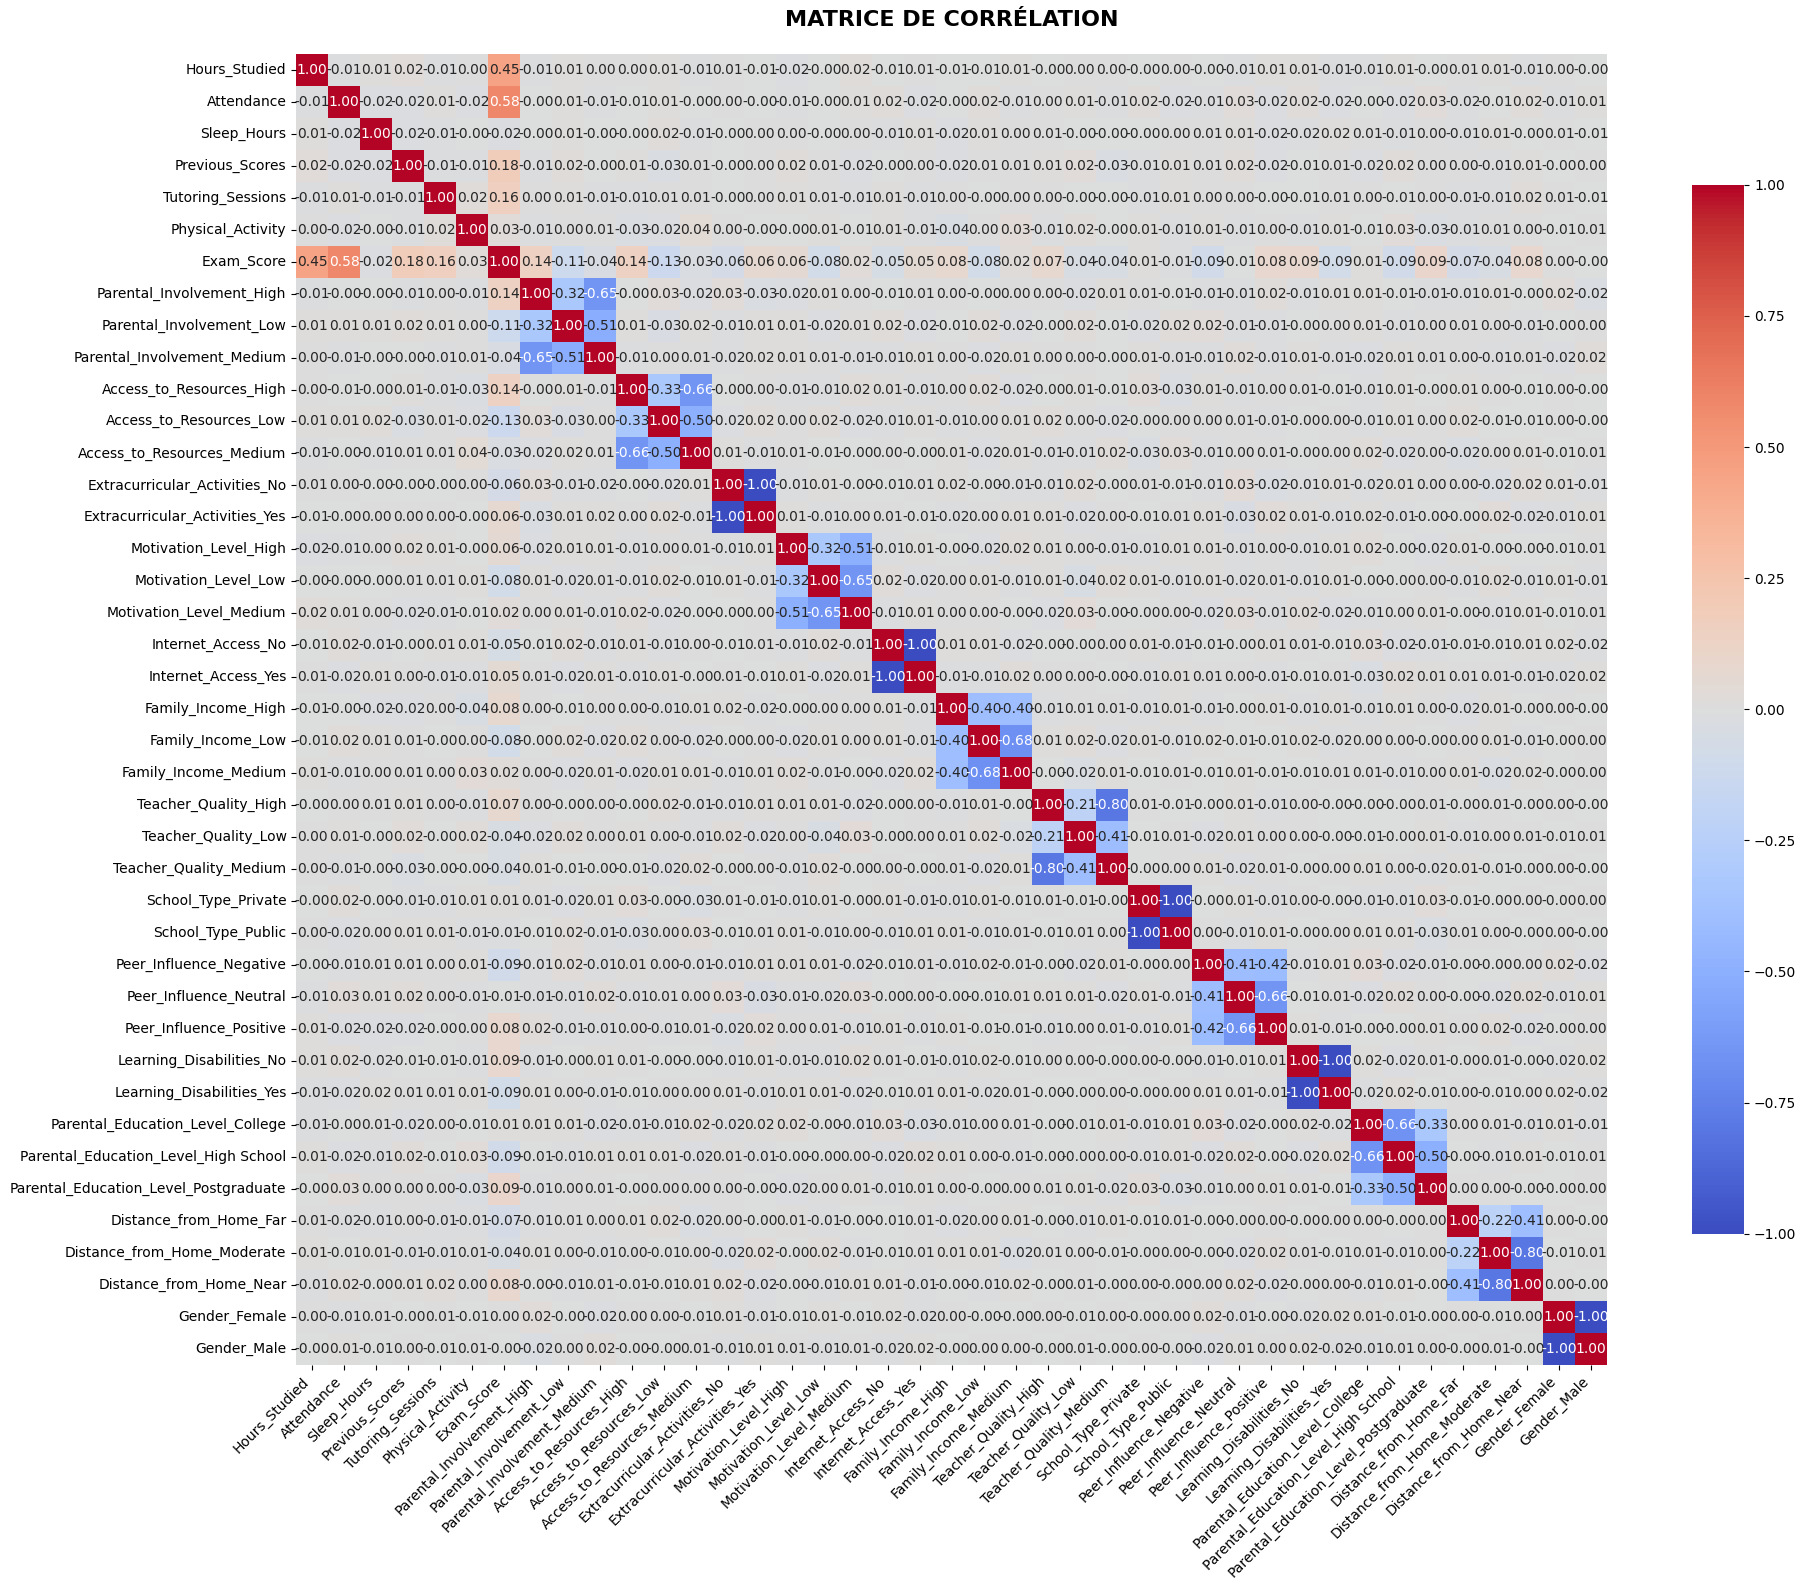

In [25]:
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title('MATRICE DE CORRÉLATION', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Pour des soucis de lisibilité, nous allons afficher les corrélations de toutes les variables par rapport à notre variable cible, celle qu'on veut prédire à savoir Exam_Score

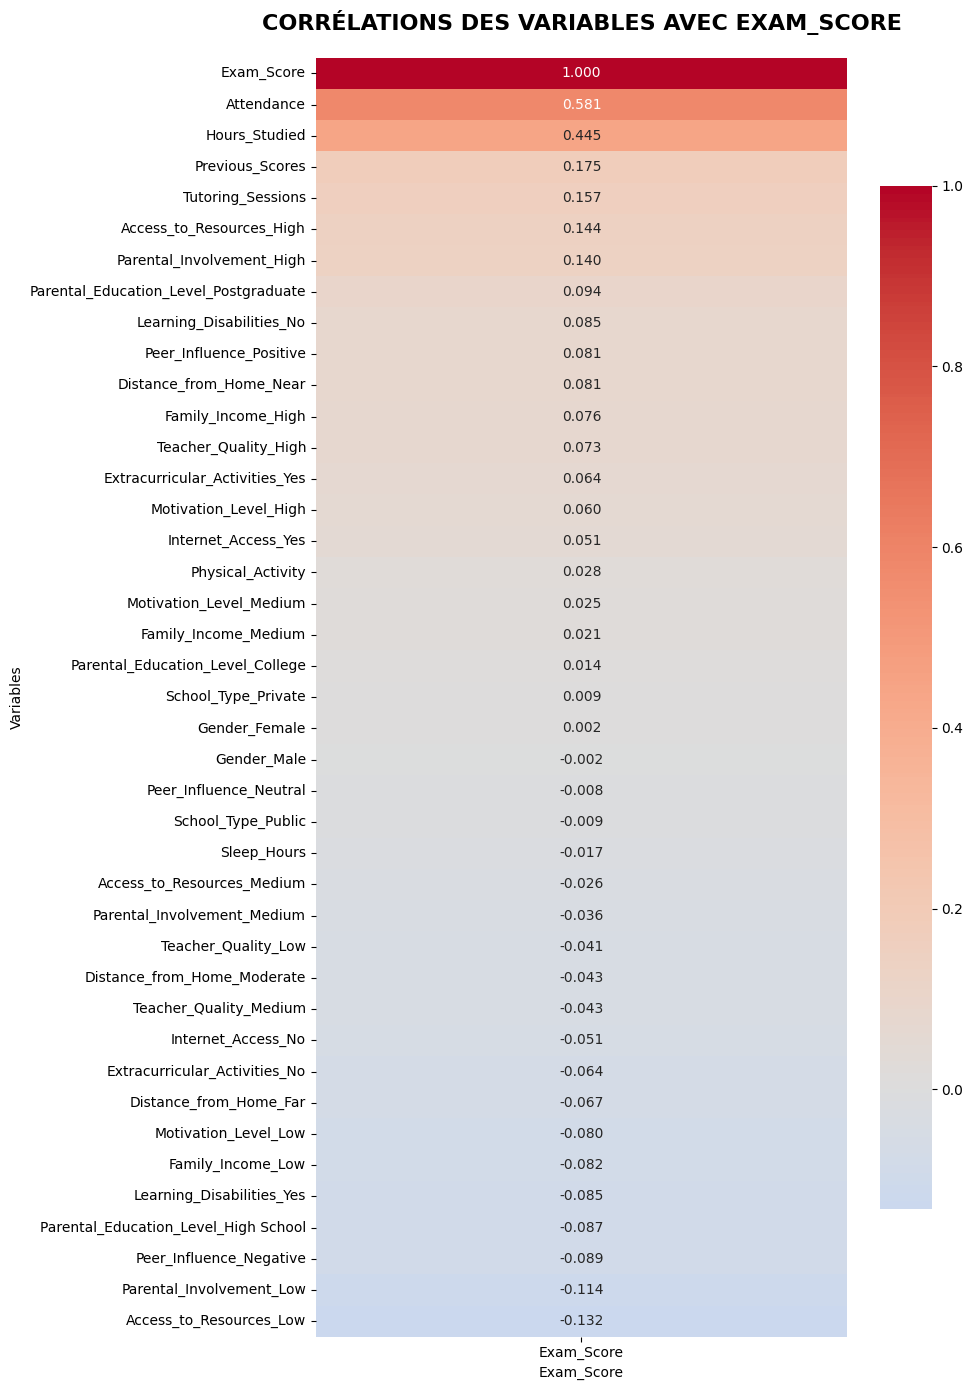

In [26]:
correlations_exam = df_encoded.corr()['Exam_Score'].sort_values(ascending=False)
correlations_exam = df_encoded.corr()['Exam_Score'].sort_values(ascending=False)

plt.figure(figsize=(10, 14))
sns.heatmap(
    correlations_exam.to_frame(),
    annot=True,
    fmt=".3f",
    cmap='coolwarm',
    center=0,
    cbar_kws={"shrink": .8}
)

plt.title('CORRÉLATIONS DES VARIABLES AVEC EXAM_SCORE',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Exam_Score')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

## **Récupération du df_filtre**

We will only work with the variables that interest us, that is, those most correlated with our target variable, which is the final grade. To select them, we will create a function that will allow us to retrieve only the variables that have exceeded a certain correlation threshold with our target variable.




In [27]:
def selectionner_variables_par_correlation(df_encoded, variable_cible='Exam_Score',
                                         seuil_correlation=0.1, afficher_resultats=True):
  correlations = df_encoded.corr()[variable_cible]
  correlations = correlations[correlations.index != variable_cible]
  variables_selectionnees = correlations[abs(correlations) >= seuil_correlation]
  variables_selectionnees = variables_selectionnees.reindex(
        variables_selectionnees.abs().sort_values(ascending=False).index
  )
  colonnes_finales = list(variables_selectionnees.index) + [variable_cible]
  df_filtre = df_encoded[colonnes_finales]

  if afficher_resultats:
    print(f"Variable cible : {variable_cible}")
    print(f"Seuil de corrélation : |{seuil_correlation}|")
    print(f"Variables originales : {df_encoded.shape[1] - 1}")
    print(f"Variables sélectionnées : {len(variables_selectionnees)}")
    print(f"Variables éliminées : {(df_encoded.shape[1] - 1) - len(variables_selectionnees)}")

  return df_filtre, variables_selectionnees



In [28]:
seuils_a_tester = [0.05, 0.1, 0.2, 0.3, 0.4]

for seuil in seuils_a_tester:
    print(f"\nSEUIL = {seuil}")
    df_temp, corr_temp = selectionner_variables_par_correlation(
        df_encoded,
        seuil_correlation=seuil
    )


SEUIL = 0.05
Variable cible : Exam_Score
Seuil de corrélation : |0.05|
Variables originales : 40
Variables sélectionnées : 25
Variables éliminées : 15

SEUIL = 0.1
Variable cible : Exam_Score
Seuil de corrélation : |0.1|
Variables originales : 40
Variables sélectionnées : 8
Variables éliminées : 32

SEUIL = 0.2
Variable cible : Exam_Score
Seuil de corrélation : |0.2|
Variables originales : 40
Variables sélectionnées : 2
Variables éliminées : 38

SEUIL = 0.3
Variable cible : Exam_Score
Seuil de corrélation : |0.3|
Variables originales : 40
Variables sélectionnées : 2
Variables éliminées : 38

SEUIL = 0.4
Variable cible : Exam_Score
Seuil de corrélation : |0.4|
Variables originales : 40
Variables sélectionnées : 2
Variables éliminées : 38


In [29]:
df_filtre, corr_temp = selectionner_variables_par_correlation(df_encoded, seuil_correlation=0.1)
df_filtre.head()

Variable cible : Exam_Score
Seuil de corrélation : |0.1|
Variables originales : 40
Variables sélectionnées : 8
Variables éliminées : 32


,Attendance,Hours_Studied,Previous_Scores,Tutoring_Sessions,Access_to_Resources_High,Parental_Involvement_High,Access_to_Resources_Low,Parental_Involvement_Low,Exam_Score
0,84,23,73,0,True,False,False,True,67
1,64,19,59,2,False,False,False,True,61
2,98,24,91,2,False,False,False,False,74
3,89,29,98,1,False,False,False,True,71
4,92,19,65,3,False,False,False,False,70


Pour la suite, nous allons faire le choix de prendre un seuil de 0.1 car on conserve tout de même 8 variables sur 40 ce qui élimine les 32 variables peu corrélées. On pense que cela représente un bon équilibre entre la réduction et la complexité du modèle et la conservation des facteurs impoprtants qui influent sur les performances à l'examen.

# **Pre-processing :**

In [30]:
df_filtre.info()
df_filtre.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Attendance                 6607 non-null   int64
 1   Hours_Studied              6607 non-null   int64
 2   Previous_Scores            6607 non-null   int64
 3   Tutoring_Sessions          6607 non-null   int64
 4   Access_to_Resources_High   6607 non-null   bool 
 5   Parental_Involvement_High  6607 non-null   bool 
 6   Access_to_Resources_Low    6607 non-null   bool 
 7   Parental_Involvement_Low   6607 non-null   bool 
 8   Exam_Score                 6607 non-null   int64
dtypes: bool(4), int64(5)
memory usage: 284.0 KB


,0
Attendance,0
Hours_Studied,0
Previous_Scores,0
Tutoring_Sessions,0
Access_to_Resources_High,0
Parental_Involvement_High,0
Access_to_Resources_Low,0
Parental_Involvement_Low,0
Exam_Score,0


No missing values ​​were found, we can proceed directly to the X/y(target) split.
We separate the target variable from X, here "Exam_Score".
We take your filtered DataFrame (df_filter) and remove the Exam_Score column. X therefore contains the 8 variables you selected (Attendance, Hours_Studied, etc.).

In [31]:
X = df_filtre.drop(columns=['Exam_Score'])
y = df_filtre['Exam_Score']

print(" Données séparées :")
print(f"Taille variable X = {X.shape}, Taille target = {y.shape}")

 Données séparées :
Taille variable X = (6607, 8), Taille target = (6607,)


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Attendance,Hours_Studied,Previous_Scores,Tutoring_Sessions,Access_to_Resources_High,Parental_Involvement_High,Access_to_Resources_Low,Parental_Involvement_Low
0,0.348375,0.504942,-0.143800,-1.213934,1.531443,-0.637216,-0.498013,1.985362
1,-1.383736,-0.162822,-1.116110,0.411451,-0.652979,-0.637216,-0.498013,1.985362
2,1.560853,0.671882,1.106313,0.411451,-0.652979,-0.637216,-0.498013,-0.503687
3,0.781403,1.506587,1.592469,-0.401242,-0.652979,-0.637216,-0.498013,1.985362
4,1.041220,-0.162822,-0.699406,1.224144,-0.652979,-0.637216,-0.498013,-0.503687


### Formalisation du problème

Le problème peut être formalisé comme une tâche de prédiction supervisée, dont
l’objectif est d’estimer la performance d’un étudiant à l’examen à partir de variables explicatives décrivant son profil, ses habitudes d’étude et son environnement.

Nous commençons par un modèle d’arbre de décision, qui offre une première estimation du lien entre les différents facteurs et la note d’examen, tout en restant facilement interprétable.

Cutting Train/test with 30% of test data

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.3, random_state=42)

print(list(X.columns))

['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_High', 'Parental_Involvement_High', 'Access_to_Resources_Low', 'Parental_Involvement_Low']


In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(" Modèle utilisé : DecisionTreeRegressor")
print(f" Mean Squared Error (MSE) : {mse:.2f}")
print(f" Coefficient de détermination (R²) : {r2:.3f}")

 Modèle utilisé : DecisionTreeRegressor
 Mean Squared Error (MSE) : 11.31
 Coefficient de détermination (R²) : 0.177


By training the model with 70% training data and 30% test data, we obtain a coefficient of determination R² = 0.177, which indicates that the model explains very little of the variance in exam scores.

Let's try adjusting the DecisionTreeRegressor parameters. Note: We cannot decrease the percentage of training data; 70/30 remains a good compromise for a dataset of this size.

The minimum number of samples that a sheet must contain is set at 5

In [35]:
tree = DecisionTreeRegressor(min_samples_leaf=5, random_state=42)

tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(" Modèle utilisé : DecisionTreeRegressor")
print(f" Mean Squared Error (MSE) : {mse:.2f}")
print(f" Coefficient de détermination (R²) : {r2:.3f}")

 Modèle utilisé : DecisionTreeRegressor
 Mean Squared Error (MSE) : 6.06
 Coefficient de détermination (R²) : 0.559


The R2 went from 0.177 to 0.559 That means we explain 56% of the variation in the scores.
The decrease in MSE reflects a significant reduction in the average error, which then explains a better generalization on the test set!


# **Grid Search**

The main objective is to increase the R² score beyond the current performance 0.559. We will use the method GridSearchCV, this tool is used to systematically explore the possible settings of the DecisionTreeRegressor. This rigorous method replaces manual parameter tuning and finds the best balance between an overly complex model and an overly simple model.
The Hyperparameters Tested are (from LAB 6): max_depth, min_samples_split, min_samples_leaf.
Validation: The process uses 5-fold Cross Validation {cv=5} on the training data. The objective is to maximize the R² score, ensuring that the selected parameters generalize well without overfitting.

In [36]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

'max_depth' = The maximum depth of the tree. Controls overfitting.
'min_samples_split'= Minimum number of samples required for a node to split. 'min_samples_leaf': Minimum number of samples that a leaf must contain.
The Grid Search will test 5 * 3 * 3 = 45 combinations.



In [37]:
base_tree = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    verbose=1
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [3, 5, 8, 10, None],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2', verbose=1)

In [38]:
print("GRID SEARCH RESULTS")
print(f"Best settings found : {grid_search.best_params_}")
print(f"Best R² on known data: {grid_search.best_score_:.3f}")

best_tree = grid_search.best_estimator_

GRID SEARCH RESULTS
Best settings found : {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best R² on known data: 0.521


In [39]:
import numpy as np
y_pred_opti = best_tree.predict(X_test)
r2_opti = r2_score(y_test, y_pred_opti)
rmse_opti = np.sqrt(mean_squared_error(y_test, y_pred_opti))

print("EVALUATION OF THE BEST MODEL ON THE TEST SET : ")
print(f"Final R² on Test : {r2_opti:.3f}")
print(f"Final RMSE on Test : {rmse_opti:.2f}")

EVALUATION OF THE BEST MODEL ON THE TEST SET : 
Final R² on Test : 0.590
Final RMSE on Test : 2.37


The difference between the R2 of the test set and that of the cross-validation can be explained because, by chance, the test set is a little easier to predict than the average of the 5 folds of the cross-validation.

# **Ensemble Learning(Bagging)**

We will use bagging, a method that trains multiple copies of the same algorithm on random subsamples of the data, then averages their predictions. This reduces variance and overfitting.

In [40]:
from sklearn.ensemble import BaggingRegressor
best_params_grid = {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
best_tree_base = DecisionTreeRegressor(random_state=42, **best_params_grid)

In [41]:
bagging_model = BaggingRegressor(
    estimator=best_tree_base,
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred_bagging = bagging_model.predict(X_test)
r2_bagging = r2_score(y_test, y_pred_bagging)
rmse_bagging = np.sqrt(mean_squared_error(y_test, y_pred_bagging))


print("RESULTS OF THE LEARNING PACKAGE")
print(f"R² final sur Test (Bagging) : {r2_bagging:.3f}")
print(f"RMSE final sur Test (Bagging) : {rmse_bagging:.2f}")

RESULTS OF THE LEARNING PACKAGE
R² final sur Test (Bagging) : 0.666
RMSE final sur Test (Bagging) : 2.14


We can clearly see a change:

1.   Standard Model (unoptimized): R2 ≈ 0.177 Optimized
2.   Decision Tree (Grid Search): R2 = 0.590
3.   Ensemble Learning (Bagging): R2 = 0.666
Our model now explains 66,6% of the variation in students' final grades. So Ensemble Learning has successfully smoothed out errors and reduced the variance of your optimized Decision Tree.

For the RSME error, we observe a significant decrease compared to the 2.37 points of our optimized model. Our model has become more accurate. On average, your grade predictions deviate from the actual grade by slightly more than two points, which is a very acceptable deviation for this type of study.

# **XGBoost**

We implemented the XGBoost Regressor (eXtreme Gradient Boosting) as an advanced model. XGBoost is a boosting algorithm that sequentially builds decision trees, with each new tree attempting to correct the errors of the previous tree.

In [42]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost Results :")
print(f"Final R² on Test:{r2_xgb:.3f}")
print(f"Final RMSE on Test: : {rmse_xgb:.2f}")

XGBoost Results :
Final R² on Test:0.659
Final RMSE on Test: : 2.16


Nous avons implémenté le XGBoost Regressor en tant que modèle avancé. Le modèle a atteint un R2 = 0.659, confirmant la performance des algorithmes de Boosting. Bien que légèrement inférieur à notre modèle Bagging (R² = 0.666), ce résultat démontre la robustesse de notre pipeline de préparation des données et répond à l'exigence d'explorer des solutions hors programme.



In [43]:
from sklearn.model_selection import RandomizedSearchCV


parametres = { 'n_estimators': [200, 400, 600, 800], 'learning_rate': [0.01, 0.05, 0.1],'max_depth': [3, 5, 7],
'subsample': [0.7, 0.85], 'colsample_bytree': [0.6, 0.8],'min_child_weight': [3, 5]}

xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

random_search = RandomizedSearchCV( estimator=xgb_base, param_distributions=parametres, n_iter=40,  # nombre de combinaisons testées
scoring='r2', cv=5, n_jobs=-1, verbose=0 )

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
best_xgb.fit(X_train, y_train)

y_pred = best_xgb.predict(X_test)

print("Best params:", random_search.best_params_)
print("R² :", round(r2_score(y_test, y_pred), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))


Best params: {'subsample': 0.85, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
R² : 0.696
RMSE : 2.04


Afin d'améliorer davantage la qualité des prédictions, nous avons ensuite optimisé XGBoost via une recherche aléatoire d’hyperparamètres (RandomizedSearchCV), en ajustant notamment la profondeur des arbres, le nombre d’estimateurs, le taux d’apprentissage et les paramètres de régularisation. Cette optimisation a permis d’obtenir une version plus stable et plus performante du modèle, atteignant un R² ≃ 0.7 sur le jeu de test. Cette progression montre qu’en ajustant correctement les paramètres, XGBoost s’adapte mieux à la complexité du problème et devient la meilleure solution parmi les modèles évalués.

# **Imputation avec Unknown**

In [44]:
df_unknown = pd.read_csv("StudentPerformanceFactors.csv")
COL_CATEGORIELLES = df_unknown.select_dtypes(include=['object']).columns.tolist()
VARIABLE_CIBLE = 'Exam_Score'

for col in COL_CATEGORIELLES:
    df_unknown[col] = df_unknown[col].fillna('Unknown')
df_unknown_encoded = pd.get_dummies(df_unknown, columns=COL_CATEGORIELLES)

correlations = df_unknown_encoded.corr()[VARIABLE_CIBLE]
variables_selectionnees = correlations[abs(correlations) >= 0.1].index.drop(VARIABLE_CIBLE)

X_unknown_filtre = df_unknown_encoded[variables_selectionnees]
y_unknown = df_unknown_encoded[VARIABLE_CIBLE]

print(f"Nombre de variables explicatives sélectionnées : {X_unknown_filtre.shape[1]}")


X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_unknown_filtre, y_unknown, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train_u_scaled = scaler.fit_transform(X_train_u)
X_test_u_scaled = scaler.transform(X_test_u)

best_params_tree = {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
best_tree_base = DecisionTreeRegressor(random_state=42, **best_params_tree)
bagging_final = BaggingRegressor(estimator=best_tree_base, n_estimators=100, random_state=42)

bagging_final.fit(X_train_u_scaled, y_train_u)

y_pred_u = bagging_final.predict(X_test_u_scaled)
r2_unknown = r2_score(y_test_u, y_pred_u)
rmse_unknown = np.sqrt(mean_squared_error(y_test_u, y_pred_u))

print("RESULTS OF THE CRITICAL ANALYSIS :")
print(f"R² : {r2_unknown:.3f}")
print(f"RMSE : {rmse_unknown:.2f}")

R2_MODE_FINAL = 0.666

print(f"R² with Mode : {R2_MODE_FINAL}")


Nombre de variables explicatives sélectionnées : 8
RESULTS OF THE CRITICAL ANALYSIS :
R² : 0.666
RMSE : 2.14
R² with Mode : 0.666


Both imputation strategies produce equivalent performance across all tested models. The improvement achieved with the optimized XGBoost model (R² ≈ 0.70, +4%) is therefore due to model tuning rather than the handling of missing values, whose very low proportion (<1.36%) does not significantly affect the results.

In [45]:
parametres_xgb = {
    'n_estimators': [200, 400, 600, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.85],
    'colsample_bytree': [0.6, 0.8],
    'min_child_weight': [3, 5]
}

xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

random_search_u = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=parametres_xgb,
    n_iter=40,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=0
)

print("\nLancement du RandomizedSearchCV pour XGBoost sur 'Unknown'")
random_search_u.fit(X_train_u_scaled, y_train_u)

best_xgb_u = random_search_u.best_estimator_

best_xgb_u.fit(X_train_u_scaled, y_train_u)

y_pred_xgb_u = best_xgb_u.predict(X_test_u_scaled)

r2_xgb_u = r2_score(y_test_u, y_pred_xgb_u)
rmse_xgb_u = np.sqrt(mean_squared_error(y_test_u, y_pred_xgb_u))


print("\n--- RÉSULTATS XGBOOST OPTIMISÉ (STRATÉGIE UNKNOWN) ---")
print("Best params:", random_search_u.best_params_)
print(f"R² final sur Test : {r2_xgb_u:.3f}")
print(f"RMSE final sur Test : {rmse_xgb_u:.2f}")

R2_XGB_MODE_BASE = 0.659
print(f"\nR² (XGBoost de base sur Mode) : {R2_XGB_MODE_BASE}")
print(f"R² (XGBoost optimisé sur Unknown) : {r2_xgb_u:.3f}")


--- Lancement du RandomizedSearchCV pour XGBoost sur 'Unknown' (cela peut prendre du temps) ---

--- RÉSULTATS XGBOOST OPTIMISÉ (STRATÉGIE UNKNOWN) ---
Best params: {'subsample': 0.7, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
R² final sur Test : 0.696
RMSE final sur Test : 2.04

R² (XGBoost de base sur Mode) : 0.659
R² (XGBoost optimisé sur Unknown) : 0.696


In [47]:
NOUVEAU_SEUIL = 0.05
VARIABLE_CIBLE = 'Exam_Score'

correlations = df_unknown_encoded.corr()[VARIABLE_CIBLE]
variables_selectionnees_larges = correlations[abs(correlations) >= NOUVEAU_SEUIL].index.drop(VARIABLE_CIBLE)

X_large = df_unknown_encoded[variables_selectionnees_larges]
y_large = df_unknown_encoded[VARIABLE_CIBLE]

print(f"Nombre de variables explicatives sélectionnées : {X_large.shape[1]}")

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_large, y_large, test_size=0.3, random_state=42
)

scaler_l = StandardScaler()
X_train_l_scaled = scaler_l.fit_transform(X_train_l)
X_test_l_scaled = scaler_l.transform(X_test_l)

import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

xgb_model_final = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print("Entraînement du XGBoost Regressor sur le set élargi (0.05)...")
xgb_model_final.fit(X_train_l_scaled, y_train_l)

y_pred_l = xgb_model_final.predict(X_test_l_scaled)
r2_large = r2_score(y_test_l, y_pred_l)
rmse_large = np.sqrt(mean_squared_error(y_test_l, y_pred_l))

print("\n--- RÉSULTATS FINAUX XGBOOST ÉLARGI ---")
print(f"R² (XGBoost, Seuil 0.05) : {r2_large:.3f}")
print(f"RMSE (XGBoost, Seuil 0.05) : {rmse_large:.2f}")

R2_MEILLEUR_ACTUEL = 0.666

print(f"\nMeilleur R² précédent (Bagging, Seuil 0.1) : {R2_MEILLEUR_ACTUEL}")

if r2_large > R2_MEILLEUR_ACTUEL:
    print("CONCLUSION : NOUVEAU MEILLEUR SCORE ! La stratégie d'inclure plus de variables est gagnante.")
else:
    print("CONCLUSION : Le seuil de 0.1 était optimal. Le bruit introduit n'a pas amélioré le modèle.")

Nombre de variables explicatives sélectionnées : 25
Entraînement du XGBoost Regressor sur le set élargi (0.05)...

--- RÉSULTATS FINAUX XGBOOST ÉLARGI ---
R² (XGBoost, Seuil 0.05) : 0.707
RMSE (XGBoost, Seuil 0.05) : 2.01

Meilleur R² précédent (Bagging, Seuil 0.1) : 0.666
CONCLUSION : NOUVEAU MEILLEUR SCORE ! La stratégie d'inclure plus de variables est gagnante.
